# The Three Classical Synthesis Problems

Mechanism synthesis answers a fundamental question: **given a desired motion, what linkage produces it?**

There are exactly three classical formulations, each controlling a different aspect of a four-bar linkage:

| Problem | What you specify | What is synthesized |
|---------|-----------------|--------------------|
| **Function generation** | Input/output angle pairs | Crank–rocker angle relationship |
| **Path generation** | Points the coupler must pass through | Coupler curve shape |
| **Motion generation** | Poses (position + orientation) of the coupler | Rigid body guidance |

This notebook demonstrates all three using `pylinkage.synthesis`, with a consistent visual style
so you can compare them side by side.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pylinkage.geometry.secants import circle_intersect
from pylinkage.synthesis import (
    Pose,
    function_generation,
    motion_generation,
    path_generation,
    solution_to_linkage,
    verify_path_generation,
)
from pylinkage.synthesis.utils import grashof_check

In [2]:
# --- Shared plotting helpers ---

import tempfile

from IPython.display import Image, display
from matplotlib.animation import FuncAnimation

COLORS = {
    "link": "#1565C0",
    "ghost": "#90CAF9",
    "ground": "#212121",
    "target": "#E53935",
    "curve": "#1565C0",
    "precision": "#43A047",
}

#: Steps per full crank rotation — high enough for smooth trails and animations.
SIM_STEPS = 1000


def draw_fourbar(ax, positions, color=COLORS["link"], alpha=1.0, lw=2, label=None):
    """Draw a four-bar in a given configuration.

    positions: list of (x, y) tuples — order: A(0), D(1), B(2), C(3).
    """
    A, D, B, C = positions[0], positions[1], positions[2], positions[3]
    for seg in [(A, B), (B, C), (C, D)]:
        ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]],
                color=color, linewidth=lw, alpha=alpha, solid_capstyle="round")
    ax.plot([A[0], D[0]], [A[1], D[1]], color=COLORS["ground"],
            linewidth=1, linestyle="--", alpha=alpha * 0.5)
    ax.plot(*A, "ks", markersize=7, alpha=alpha, zorder=5)
    ax.plot(*D, "k^", markersize=7, alpha=alpha, zorder=5)
    if label:
        ax.plot([], [], color=color, linewidth=lw, label=label)


def simulate_linkage(linkage, iterations=SIM_STEPS):
    """Simulate and return list of valid position tuples.

    Uses skip_unbuildable=True so that non-Grashof linkages continue
    past dead zones instead of losing the entire remaining trajectory.
    """
    linkage.rebuild()
    frames = []
    for pos in linkage.step(iterations=iterations, skip_unbuildable=True):
        if all(p[0] is not None for p in pos):
            frames.append(pos)
    return frames


def draw_ghosts(ax, loci, n_ghosts=12, color=COLORS["ghost"], alpha=0.15):
    """Draw ghosted mechanism frames from simulation loci."""
    every = max(1, len(loci) // n_ghosts)
    for i in range(0, len(loci), every):
        draw_fourbar(ax, loci[i], color=color, alpha=alpha, lw=1)


def draw_pose_arrow(ax, pose, length=0.5, color=COLORS["target"], lw=2, alpha=1.0):
    """Draw a pose as a position dot + orientation arrow."""
    dx = length * math.cos(pose.angle)
    dy = length * math.sin(pose.angle)
    ax.annotate("", xy=(pose.x + dx, pose.y + dy), xytext=(pose.x, pose.y),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw),
                alpha=alpha)
    ax.plot(pose.x, pose.y, "o", color=color, markersize=8, zorder=5, alpha=alpha)


def animate_fourbar(loci, title="", markers=None, marker_color=None,
                    trail_idx=None, figsize=(7, 5), fps=30):
    """Create and display a GIF animation of a four-bar linkage."""
    if not loci:
        print("No frames to animate.")
        return None

    mc = marker_color or COLORS["precision"]

    # Target ~120 animation frames -> ~4 s at 30 fps
    step = max(1, len(loci) // 120)
    frames = loci[::step]

    # Compute axis limits
    all_x = [p[j][0] for p in loci for j in range(min(4, len(p)))]
    all_y = [p[j][1] for p in loci for j in range(min(4, len(p)))]
    pad = 0.3
    xmin, xmax = min(all_x) - pad, max(all_x) + pad
    ymin, ymax = min(all_y) - pad, max(all_y) + pad

    fig, ax = plt.subplots(figsize=figsize)

    # Static elements
    A0, D0 = frames[0][0], frames[0][1]
    ax.plot(*A0, "ks", markersize=8, zorder=5)
    ax.plot(*D0, "k^", markersize=8, zorder=5)
    ax.plot([A0[0], D0[0]], [A0[1], D0[1]], color=COLORS["ground"],
            lw=1, ls="--", alpha=0.4)

    if markers:
        for m in markers:
            if hasattr(m, "angle"):
                draw_pose_arrow(ax, m, length=0.4, color=mc)
            else:
                ax.plot(m[0], m[1], "o", color=mc, markersize=10, zorder=4)

    if trail_idx is not None:
        tx = [p[trail_idx][0] for p in loci]
        ty = [p[trail_idx][1] for p in loci]
        ax.plot(tx, ty, color=COLORS["target"], lw=1, alpha=0.4)

    # Animated elements
    line_ab, = ax.plot([], [], color=COLORS["link"], lw=2.5, solid_capstyle="round")
    line_bc, = ax.plot([], [], color=COLORS["link"], lw=2.5, solid_capstyle="round")
    line_cd, = ax.plot([], [], color=COLORS["link"], lw=2.5, solid_capstyle="round")
    dot_b, = ax.plot([], [], "o", color=COLORS["link"], markersize=5, zorder=5)
    dot_c, = ax.plot([], [], "o", color=COLORS["link"], markersize=5, zorder=5)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    def update(i):
        pos = frames[i]
        A, D, B, C = pos[0], pos[1], pos[2], pos[3]
        line_ab.set_data([A[0], B[0]], [A[1], B[1]])
        line_bc.set_data([B[0], C[0]], [B[1], C[1]])
        line_cd.set_data([C[0], D[0]], [C[1], D[1]])
        dot_b.set_data([B[0]], [B[1]])
        dot_c.set_data([C[0]], [C[1]])
        return line_ab, line_bc, line_cd, dot_b, dot_c

    anim = FuncAnimation(fig, update, frames=len(frames),
                         interval=1000 // fps, blit=True)

    # Save to temp file, read back, display inline
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
        anim.save(tmp.name, writer="pillow", fps=fps)
        tmp_path = tmp.name
    plt.close(fig)
    display(Image(filename=tmp_path))

---
## 1. Function Generation — Freudenstein’s Equation

**Goal:** design a four-bar where turning the crank by angle $\theta_2$
produces a specific rocker angle $\theta_4$.

The governing equation (Freudenstein, 1955):

$$R_1 \cos\theta_4 - R_2 \cos\theta_2 + R_3 - \cos(\theta_2 - \theta_4) = 0$$

Three angle pairs $\Rightarrow$ three linear equations in three unknowns
$(R_1, R_2, R_3)$ $\Rightarrow$ unique solution.

In [3]:
# Desired transfer function: output leads input at low angles, converges at high
angle_pairs = [
    (math.radians(30),  math.radians(75)),   # +45° lead
    (math.radians(75),  math.radians(90)),   # +15° lead
    (math.radians(135), math.radians(135)),  #   0° lead
]

func_result = function_generation(
    angle_pairs, ground_length=1.0, require_grashof=False,
)

print(f"Solutions: {len(func_result.solutions)}")
sol_f = func_result.raw_solutions[0]
gt = grashof_check(sol_f.crank_length, sol_f.coupler_length,
                   sol_f.rocker_length, sol_f.ground_length)
print(f"Links: a={sol_f.crank_length:.3f}  b={sol_f.coupler_length:.3f}  "
      f"c={sol_f.rocker_length:.3f}  d={sol_f.ground_length:.3f}")
print(f"Grashof type: {gt.name}")

Solutions: 1
Links: a=0.782  b=0.843  c=1.030  d=1.000
Grashof type: GRASHOF_CRANK_ROCKER


In [4]:
# Compute actual transfer function across full crank sweep
A_f, D_f = sol_f.ground_pivot_a, sol_f.ground_pivot_d
a, b, c = sol_f.crank_length, sol_f.coupler_length, sol_f.rocker_length

theta2_sweep = np.linspace(0.05, math.pi - 0.05, 300)
theta2_valid, theta4_actual = [], []

for t2 in theta2_sweep:
    Bx = A_f[0] + a * math.cos(t2)
    By = A_f[1] + a * math.sin(t2)
    n, x1, y1, x2, y2 = circle_intersect(Bx, By, b, D_f[0], D_f[1], c)
    if n == 0:
        continue
    t4 = math.atan2(y1 - D_f[1], x1 - D_f[0])
    if n == 2:
        t4b = math.atan2(y2 - D_f[1], x2 - D_f[0])
        if t4b > t4:
            t4 = t4b
    theta2_valid.append(t2)
    theta4_actual.append(t4)

theta2_valid = np.array(theta2_valid)
theta4_actual = np.array(theta4_actual)

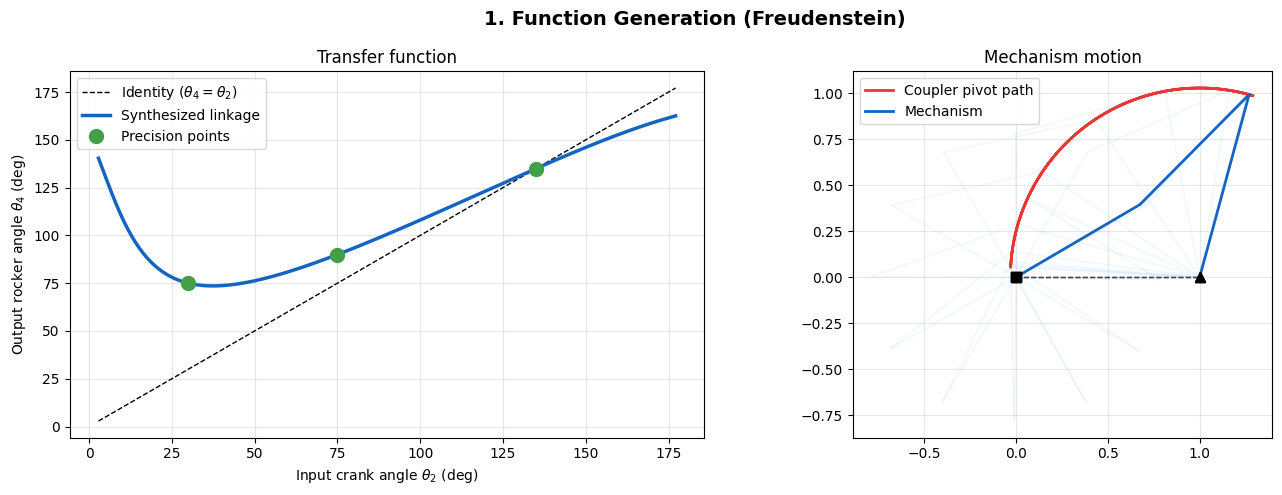

In [5]:
# Simulate linkage for ghost drawing
linkage_f = solution_to_linkage(sol_f, name="func-gen", iterations=SIM_STEPS)
loci_f = simulate_linkage(linkage_f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: transfer function
ax1.plot(np.degrees(theta2_valid), np.degrees(theta2_valid),
         "k--", lw=1, label=r"Identity ($\theta_4=\theta_2$)")
ax1.plot(np.degrees(theta2_valid), np.degrees(theta4_actual),
         color=COLORS["curve"], lw=2.5, label="Synthesized linkage")
for t2, t4 in angle_pairs:
    ax1.plot(math.degrees(t2), math.degrees(t4), "o",
            color=COLORS["precision"], markersize=10, zorder=5)
ax1.plot([], [], "o", color=COLORS["precision"], markersize=10,
         label="Precision points")
ax1.set_xlabel(r"Input crank angle $\theta_2$ (deg)")
ax1.set_ylabel(r"Output rocker angle $\theta_4$ (deg)")
ax1.set_title("Transfer function")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: mechanism motion
draw_ghosts(ax2, loci_f)
cx = [p[3][0] for p in loci_f]
cy = [p[3][1] for p in loci_f]
ax2.plot(cx, cy, color=COLORS["target"], lw=2, label="Coupler pivot path")
draw_fourbar(ax2, loci_f[0], label="Mechanism")
ax2.set_aspect("equal")
ax2.set_title("Mechanism motion")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

fig.suptitle("1. Function Generation (Freudenstein)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("synthesis_function.svg", bbox_inches="tight")
plt.show()

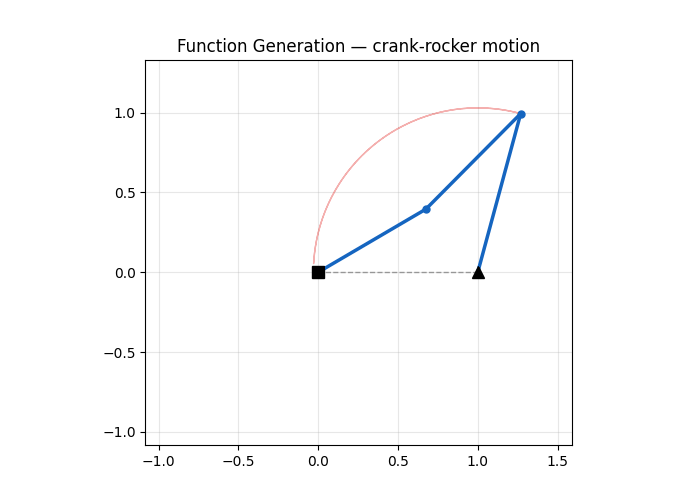

In [6]:
# Animate the function generation linkage
animate_fourbar(loci_f, title="Function Generation — crank-rocker motion",
                trail_idx=3);

The green dots sit exactly on the synthesized curve — zero error at precision points.
Between them, the **structural error** is the unavoidable deviation inherent to
finite-precision synthesis.

---
## 2. Path Generation — Burmester Theory

**Goal:** design a four-bar whose coupler point traces a curve
passing through specified positions.

Unlike function generation, we don’t control timing — only *where*
the coupler goes, not *when*. The coupler orientation at each point
is a free variable, searched over automatically.

Mathematically, the problem uses **Burmester’s circle point / center point curves**:
points on the coupler whose successive positions are concyclic.

In [7]:
# D-shaped locus: flat bottom + arched top (good for walking feet)
precision_points = [
    (-1.0,  0.0),   # left end of flat stance
    ( 0.0, -0.3),   # bottom of arc (swing phase)
    ( 1.0,  0.0),   # right end of flat stance
]

path_result = path_generation(
    precision_points,
    max_solutions=5,
    require_grashof=False,
)

print(f"Solutions found: {len(path_result.solutions)}")
if path_result.warnings:
    for w in path_result.warnings:
        print(f"  Warning: {w[:80]}..." if len(w) > 80 else f"  Warning: {w}")

Solutions found: 5


In [8]:
# Pick the best solution and simulate
if path_result.solutions:
    linkage_p = path_result.solutions[0]
    sol_p = path_result.raw_solutions[0]
    loci_p = simulate_linkage(linkage_p)

    # Verify precision
    ok, dists = verify_path_generation(linkage_p, precision_points)
    print(f"Verified: {ok}")
    for i, (pt, d) in enumerate(zip(precision_points, dists, strict=False)):
        print(f"  Point {i+1} {pt}: distance = {d:.4f}")

    gt_p = grashof_check(sol_p.crank_length, sol_p.coupler_length,
                         sol_p.rocker_length, sol_p.ground_length)
    print(f"Links: a={sol_p.crank_length:.3f}  b={sol_p.coupler_length:.3f}  "
          f"c={sol_p.rocker_length:.3f}  d={sol_p.ground_length:.3f}")
    print(f"Grashof type: {gt_p.name}")
else:
    print("No solutions found — try relaxing constraints.")

Verified: True
  Point 1 (-1.0, 0.0): distance = 0.0000
  Point 2 (0.0, -0.3): distance = 0.0106
  Point 3 (1.0, 0.0): distance = 0.0056
Links: a=0.592  b=0.800  c=0.808  d=0.619
Grashof type: GRASHOF_CRANK_ROCKER


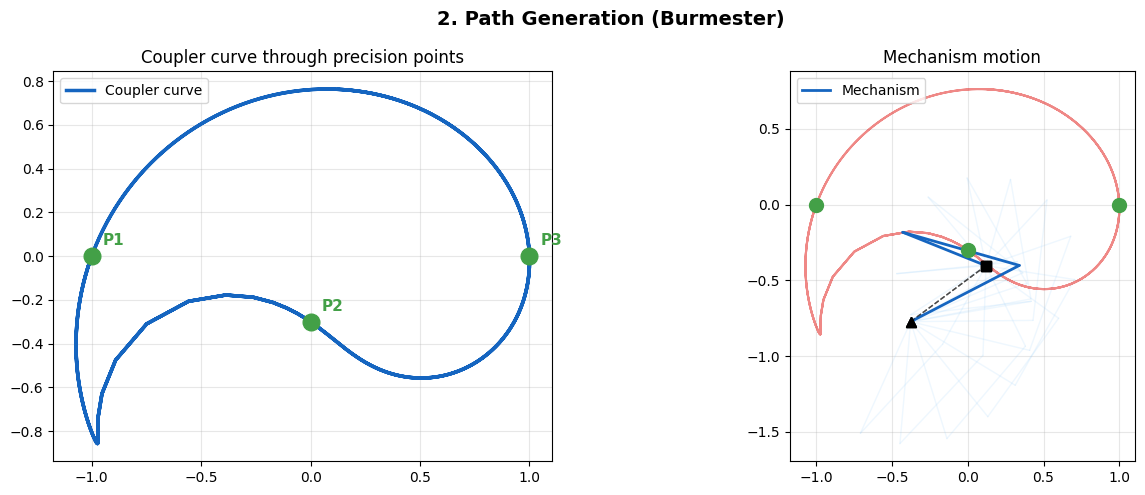

In [9]:
if path_result.solutions:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: coupler curve with precision points
    n_joints = len(loci_p[0])
    cp_idx = n_joints - 1
    cpx = [p[cp_idx][0] for p in loci_p]
    cpy = [p[cp_idx][1] for p in loci_p]
    ax1.plot(cpx, cpy, color=COLORS["curve"], lw=2.5, label="Coupler curve")
    for i, pt in enumerate(precision_points):
        ax1.plot(*pt, "o", color=COLORS["precision"], markersize=12, zorder=5)
        ax1.annotate(f"P{i+1}", pt, textcoords="offset points",
                     xytext=(8, 8), fontsize=11, fontweight="bold",
                     color=COLORS["precision"])
    ax1.set_aspect("equal")
    ax1.set_title("Coupler curve through precision points")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Right: mechanism motion
    draw_ghosts(ax2, loci_p)
    ax2.plot(cpx, cpy, color=COLORS["target"], lw=1.5, alpha=0.6)
    draw_fourbar(ax2, loci_p[0], label="Mechanism")
    for pt in precision_points:
        ax2.plot(*pt, "o", color=COLORS["precision"], markersize=10, zorder=5)
    ax2.set_aspect("equal")
    ax2.set_title("Mechanism motion")
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)

    fig.suptitle("2. Path Generation (Burmester)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("synthesis_path.svg", bbox_inches="tight")
    plt.show()

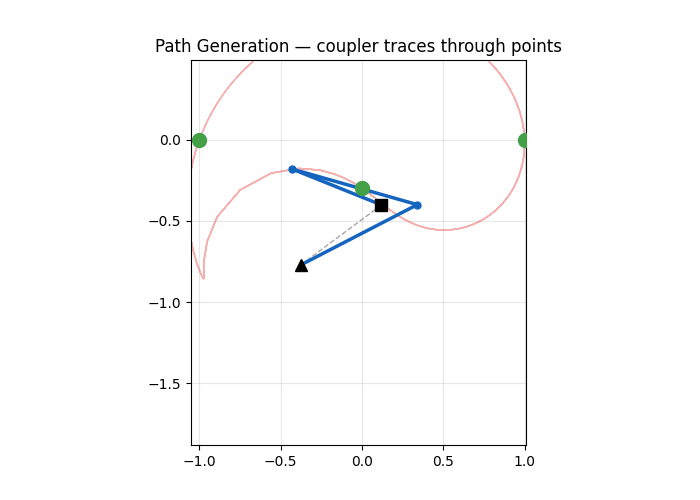

In [10]:
# Animate the path generation linkage
if loci_p:
    cp_idx_p = len(loci_p[0]) - 1
    animate_fourbar(loci_p, title="Path Generation — coupler traces through points",
                    markers=precision_points, trail_idx=cp_idx_p)

The coupler curve passes near all three precision points. The shape of the
curve *between* the points is not controlled — that’s the nature of
finite-precision synthesis.

---
## 3. Motion Generation — Rigid Body Guidance

**Goal:** guide the coupler body through specified **poses** (position + orientation).

This is the most constrained of the three problems: at each precision
position, both the location *and* the rotation of the coupler body must match.

The mathematical foundation is the same Burmester theory as path generation,
but with orientations fully specified (no free variables to search over).

In [11]:
# Three poses: gentle pick-rotate-place (small orientation changes)
poses = [
    Pose(0.0, 0.0, math.radians(0)),    # start: horizontal
    Pose(1.0, 0.8, math.radians(20)),   # mid: lifted and tilted
    Pose(2.0, 0.0, math.radians(45)),   # end: placed, rotated 45°
]

motion_result = motion_generation(
    poses,
    max_solutions=10,
    require_grashof=False,
)

print(f"Solutions found: {len(motion_result.solutions)}")
if motion_result.warnings:
    for w in motion_result.warnings:
        print(f"  Warning: {w[:80]}..." if len(w) > 80 else f"  Warning: {w}")

Solutions found: 10


In [12]:
# Try each solution and pick the one that simulates the longest arc
linkage_m, sol_m, loci_m = None, None, []

if motion_result.solutions:
    best_len = 0
    for lnk, raw in zip(
        motion_result.solutions, motion_result.raw_solutions, strict=False
    ):
        frames = simulate_linkage(lnk)
        if len(frames) > best_len:
            best_len = len(frames)
            linkage_m, sol_m, loci_m = lnk, raw, frames

if sol_m is not None:
    gt_m = grashof_check(sol_m.crank_length, sol_m.coupler_length,
                         sol_m.rocker_length, sol_m.ground_length)
    print(f"Best solution: {best_len} frames out of {SIM_STEPS}")
    print(f"Links: a={sol_m.crank_length:.3f}  b={sol_m.coupler_length:.3f}  "
          f"c={sol_m.rocker_length:.3f}  d={sol_m.ground_length:.3f}")
    print(f"Grashof type: {gt_m.name}")
else:
    print("No solutions could be simulated.")

Best solution: 1000 frames out of 1000
Links: a=0.950  b=1.182  c=1.065  d=1.200
Grashof type: GRASHOF_CRANK_ROCKER


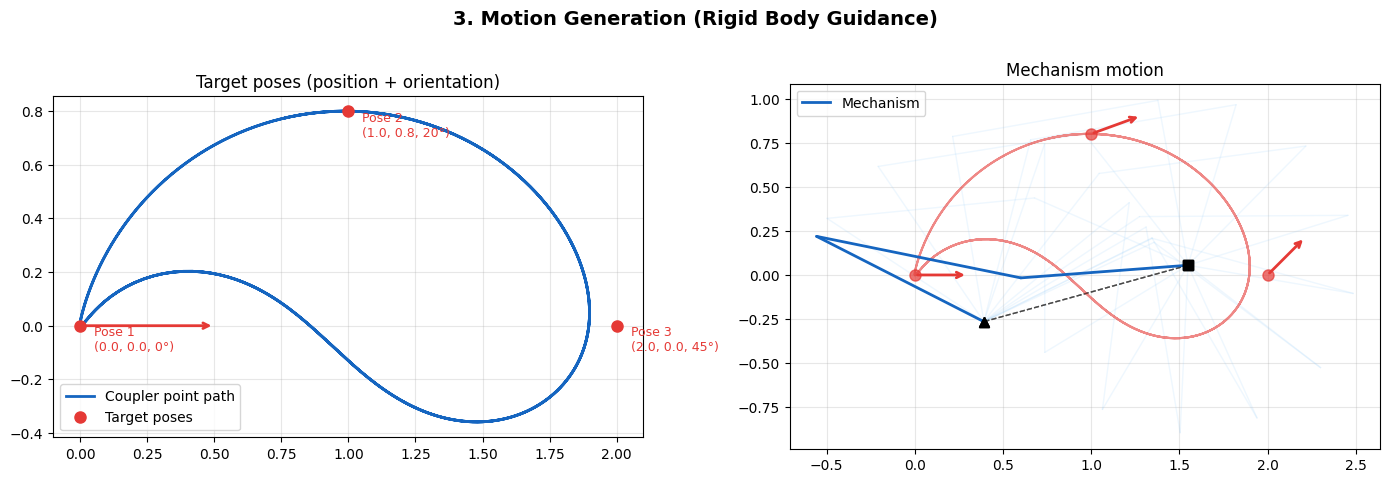

In [13]:
if loci_m:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    n_joints = len(loci_m[0])
    cp_idx = n_joints - 1
    cpx = [p[cp_idx][0] for p in loci_m]
    cpy = [p[cp_idx][1] for p in loci_m]
    ax1.plot(cpx, cpy, color=COLORS["curve"], lw=2, label="Coupler point path")
    for i, pose in enumerate(poses):
        draw_pose_arrow(ax1, pose)
        ax1.annotate(f"Pose {i+1}\n({pose.x}, {pose.y}, {math.degrees(pose.angle):.0f}\u00b0)",
                     (pose.x, pose.y), textcoords="offset points",
                     xytext=(10, -18), fontsize=9, color=COLORS["target"])
    ax1.plot([], [], "o", color=COLORS["target"], markersize=8, label="Target poses")
    ax1.set_aspect("equal")
    ax1.set_title("Target poses (position + orientation)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    draw_ghosts(ax2, loci_m)
    ax2.plot(cpx, cpy, color=COLORS["target"], lw=1.5, alpha=0.6)
    draw_fourbar(ax2, loci_m[0], label="Mechanism")
    for pose in poses:
        draw_pose_arrow(ax2, pose, length=0.3, alpha=0.7)
    ax2.set_aspect("equal")
    ax2.set_title("Mechanism motion")
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)

    fig.suptitle("3. Motion Generation (Rigid Body Guidance)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("synthesis_motion.svg", bbox_inches="tight")
    plt.show()
else:
    print("No frames to plot.")

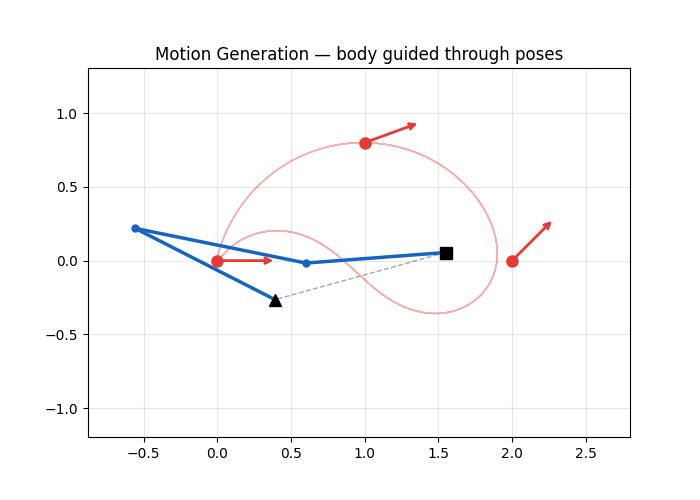

In [14]:
# Animate the motion generation linkage
if loci_m:
    cp_idx_m = len(loci_m[0]) - 1
    animate_fourbar(loci_m, title="Motion Generation — body guided through poses",
                    markers=poses, marker_color=COLORS["target"],
                    trail_idx=cp_idx_m)

The arrows show the desired orientation at each pose. Motion generation
ensures the coupler body matches both position and rotation at these points.

---
## Comparison

Let’s put all three side by side to see how the same mathematical framework
(Burmester theory for path/motion, Freudenstein for function) produces
different mechanisms from different specifications.

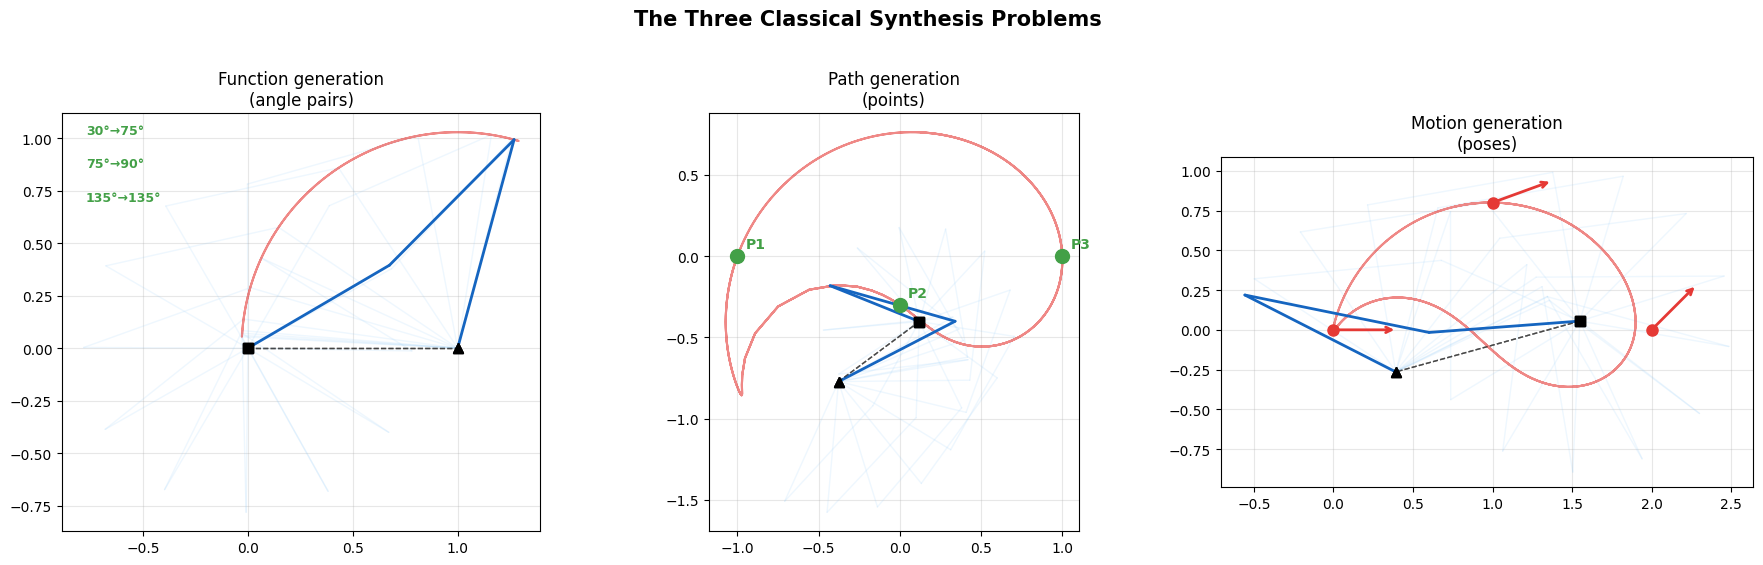

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
titles = [
    "Function generation\n(angle pairs)",
    "Path generation\n(points)",
    "Motion generation\n(poses)",
]

# --- Panel 1: Function generation ---
ax = axes[0]
draw_ghosts(ax, loci_f)
cx_f = [p[3][0] for p in loci_f]
cy_f = [p[3][1] for p in loci_f]
ax.plot(cx_f, cy_f, color=COLORS["target"], lw=1.5, alpha=0.6)
draw_fourbar(ax, loci_f[0])
for t2, t4 in angle_pairs:
    ax.annotate(f"{math.degrees(t2):.0f}\u00b0\u2192{math.degrees(t4):.0f}\u00b0",
                xy=(0.05, 0.95 - angle_pairs.index((t2, t4)) * 0.08),
                xycoords="axes fraction", fontsize=9,
                color=COLORS["precision"], fontweight="bold")

# --- Panel 2: Path generation ---
ax = axes[1]
if loci_p:
    draw_ghosts(ax, loci_p)
    n_jp = len(loci_p[0])
    cpx_p = [p[n_jp - 1][0] for p in loci_p]
    cpy_p = [p[n_jp - 1][1] for p in loci_p]
    ax.plot(cpx_p, cpy_p, color=COLORS["target"], lw=1.5, alpha=0.6)
    draw_fourbar(ax, loci_p[0])
    for i, pt in enumerate(precision_points):
        ax.plot(*pt, "o", color=COLORS["precision"], markersize=10, zorder=5)
        ax.annotate(f"P{i+1}", pt, textcoords="offset points",
                     xytext=(6, 6), fontsize=10, color=COLORS["precision"],
                     fontweight="bold")

# --- Panel 3: Motion generation ---
ax = axes[2]
if loci_m:
    draw_ghosts(ax, loci_m)
    n_jm = len(loci_m[0])
    cpx_m = [p[n_jm - 1][0] for p in loci_m]
    cpy_m = [p[n_jm - 1][1] for p in loci_m]
    ax.plot(cpx_m, cpy_m, color=COLORS["target"], lw=1.5, alpha=0.6)
    draw_fourbar(ax, loci_m[0])
    for pose in poses:
        draw_pose_arrow(ax, pose, length=0.4)
else:
    ax.text(0.5, 0.5, "No simulatable\nsolution found",
            transform=ax.transAxes, ha="center", va="center", fontsize=12)

for ax, title in zip(axes, titles, strict=False):
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

fig.suptitle("The Three Classical Synthesis Problems",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("synthesis_comparison.svg", bbox_inches="tight")
plt.show()

## Summary table

| | Function | Path | Motion |
|---|---|---|---|
| **You specify** | $\theta_2 \to \theta_4$ pairs | $(x, y)$ points | $(x, y, \theta)$ poses |
| **Constrains** | Angle relationship | Coupler curve | Body trajectory |
| **Method** | Freudenstein (linear) | Burmester + orientation search | Burmester (direct) |
| **Free variables** | None | Coupler orientation | None |
| **3 specifications** | Unique exact solution | Continuous curve of solutions | Continuous curve of solutions |
| **4 specifications** | Least-squares fit | Up to 6 discrete solutions | Up to 6 discrete solutions |
| **5 specifications** | Least-squares fit | 0–2 solutions | 0–2 solutions |
| **Typical use** | Mechanical computing, coordinated motion | Walking feet, cam replacement | Pick-and-place, door hinges |

All three synthesis types are available in `pylinkage.synthesis` and produce
standard `Linkage` objects that can be simulated, optimized, and visualized
with the rest of the pylinkage toolchain.